In [62]:
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib import pyplot as plt
from scipy.spatial import Delaunay

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['pdf.fonttype']=42
plt.rcParams.update({'font.sans-serif':'Helvetica'})
plt.rcParams.update({'font.size':7})


def alpha_shape(points, alpha, only_outer=True):
    """
    Compute the alpha shape (concave hull) of a set of points.
    :param points: np.array of shape (n,2) points.
    :param alpha: alpha value.
    :param only_outer: boolean value to specify if we keep only the outer border
    or also inner edges.
    :return: set of (i,j) pairs representing edges of the alpha-shape. (i,j) are
    the indices in the points array.
    """
    assert points.shape[0] > 3, "Need at least four points"
    def add_edge(edges, i, j):
        """
        Add an edge between the i-th and j-th points,
        if not in the list already
        """
        if (i, j) in edges or (j, i) in edges:
            # already added
            assert (j, i) in edges, "Can't go twice over same directed edge right?"
            if only_outer:
                # if both neighboring triangles are in shape, it's not a boundary edge
                edges.remove((j, i))
            return
        edges.add((i, j))
    tri = Delaunay(points)
    edges = set()
    # Loop over triangles:
    # ia, ib, ic = indices of corner points of the triangle
    for ia, ib, ic in tri.vertices:
        pa = points[ia]
        pb = points[ib]
        pc = points[ic]
        # Computing radius of triangle circumcircle
        # www.mathalino.com/reviewer/derivation-of-formulas/derivation-of-formula-for-radius-of-circumcircle
        a = np.sqrt((pa[0] - pb[0]) ** 2 + (pa[1] - pb[1]) ** 2)
        b = np.sqrt((pb[0] - pc[0]) ** 2 + (pb[1] - pc[1]) ** 2)
        c = np.sqrt((pc[0] - pa[0]) ** 2 + (pc[1] - pa[1]) ** 2)
        s = (a + b + c) / 2.0
        area = np.sqrt(s * (s - a) * (s - b) * (s - c))
        circum_r = a * b * c / (4.0 * area)
        if circum_r < alpha:
            add_edge(edges, ia, ib)
            add_edge(edges, ib, ic)
            add_edge(edges, ic, ia)
    return edges
import seaborn as sns
from matplotlib import pyplot as plt
def dotplot(data, x, y, color, size, sizes=(0,50), colors=(-0.5,0.5), dpi=300):
    #normalize = mcolors.TwoSlopeNorm(vcenter=0, vmin=colors[0], vmax=colors[1])
    # colormap = cm.PiYG
    if colors:
        data[color]=data[color].clip(colors[0], colors[1])





    data[x]=data[x].astype("category")
    data[y]=data[y].astype("category")

    x_lab=data[x].cat.categories
    y_lab=data[y].cat.categories

    f=sns.clustermap(data.pivot(index=y, columns=x, values=color),figsize=(0.1,0.1), cmap='PiYG')

    x_lab=x_lab[f.dendrogram_col.reordered_ind]
    y_lab=y_lab[f.dendrogram_row.reordered_ind]


    data[x]=data[x].cat.reorder_categories(x_lab)
    data[y]=data[y].cat.reorder_categories(y_lab)
    data=data.sort_values([x, y])


    plt.figure(figsize=(0.15*len(x_lab),0.15*len(y_lab)), dpi=dpi)

    ax =sns.scatterplot(data=data,
                        y=y,
                        x=x,
                        hue=color,
                        palette="PiYG",
                        size=size,
                        sizes=sizes)

    ax.set_xlim(-0.5, -0.5+len(x_lab))
    ax.set_ylim(-0.5, -0.5+len(y_lab))

    ax.set_xticklabels(x_lab,rotation = 90)
    plt.legend(bbox_to_anchor=(1.05,1),
               loc='upper left',
               borderaxespad=0)
    return ax
plt.rcParams['pdf.fonttype']=42
plt.rcParams.update({'font.sans-serif':'Helvetica'})
plt.rcParams.update({'font.size':7})

In [11]:
adata=sc.read_h5ad("out/CID44971stf_results_tfa_only.h5ad")
adata=adata[adata.obs['pathology'] !="Artefact"]
sc.tl.rank_genes_groups(adata, layer='stan_tfa', groupby='pathology', method="wilcoxon")
categories=adata.obs['pathology'].cat.categories


Trying to set attribute `.uns` of view, copying.


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


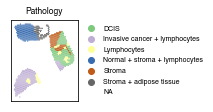

In [12]:
plt.rcParams['pdf.fonttype']=42
plt.rcParams.update({'font.sans-serif':'Helvetica'})
plt.rcParams.update({'font.size':7})

f, ax=plt.subplots(figsize=(1.5,1.5))
sc.pl.spatial(adata, color='pathology', palette='Accent', alpha_img=0, size=1.6, ax=ax, show=False, title="Pathology")
ax.set_xlabel("")
ax.set_ylabel("")

plt.savefig("CID44971_pathology.pdf", bbox_inches='tight')

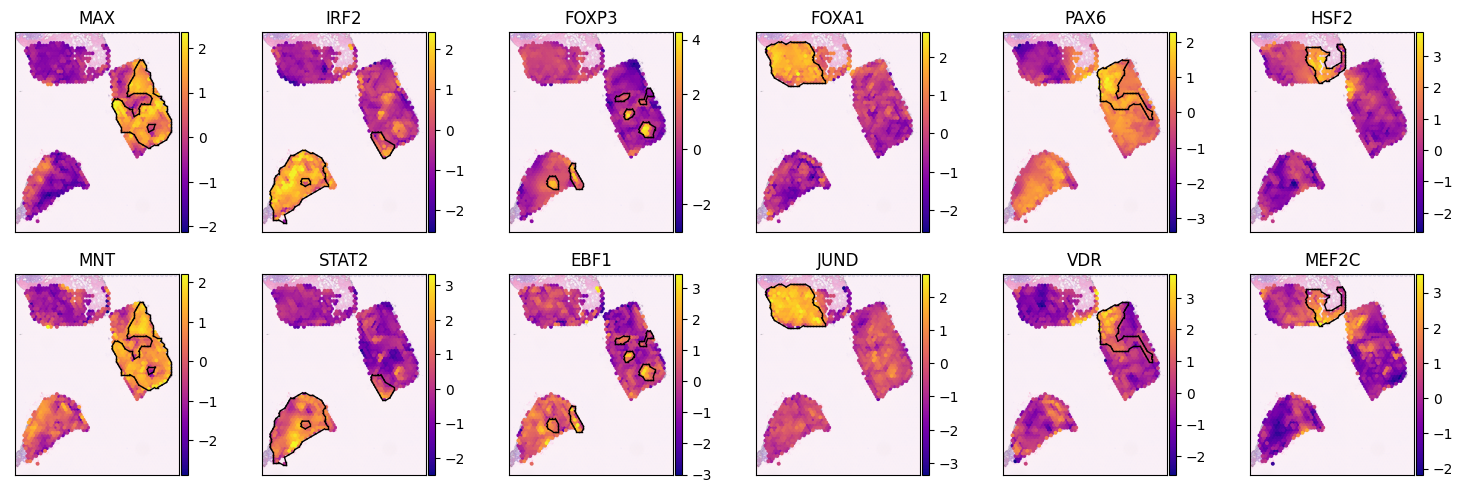

In [26]:
f, axs = plt.subplots(2, 6, figsize=(15,5))
for i in range(6):
    points=np.asarray(adata[adata.obs['pathology']==categories[i]].obsm['spatial']*adata.uns['spatial']['CID44971']['scalefactors']['tissue_hires_scalef'])
    points=np.vstack((points +[-10,10], points +[-10,-10], points +[10,10], points +[10,-10]))
    edges=alpha_shape(points, alpha=25, only_outer=True)
    for j in range(2):
        tf=adata.uns['rank_genes_groups']['names'][j][i]

        sc.pl.spatial(adata, color=tf, size=2, cmap='plasma', alpha_img=0.5, ax=axs[j,i], show=False)
        axs[j,i].set_xlabel("")
        axs[j,i].set_ylabel("")
        for ii, jj in edges:
            axs[j,i].plot(points[[ii, jj], 0], points[[ii, jj], 1], 'k',linewidth=0.5, alpha=0.5)

plt.tight_layout()

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; rega

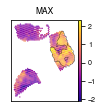

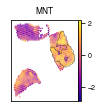

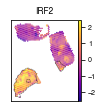

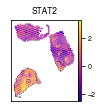

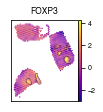

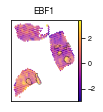

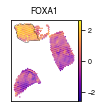

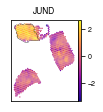

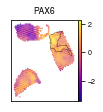

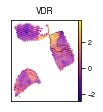

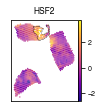

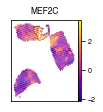

In [28]:

for i in range(6):
    points=np.asarray(adata[adata.obs['pathology']==categories[i]].obsm['spatial']*adata.uns['spatial']['CID44971']['scalefactors']['tissue_hires_scalef'])
    points=np.vstack((points +[-10,10], points +[-10,-10], points +[10,10], points +[10,-10]))
    edges=alpha_shape(points, alpha=25, only_outer=True)
    for j in range(2):
        f, ax=plt.subplots(figsize=(1.5,1.5))

        tf=adata.uns['rank_genes_groups']['names'][j][i]
        sc.pl.spatial(adata, color=tf, size=1.6, cmap='plasma', alpha_img=0, ax=ax, show=False)
        ax.set_xlabel("")
        ax.set_ylabel("")
        for ii, jj in edges:
            ax.plot(points[[ii, jj], 0], points[[ii, jj], 1], 'k', linewidth=0.5, alpha=0.5)
        plt.savefig("CID44971_"+categories[i]+"_"+str(j)+"_"+tf+".pdf", bbox_inches='tight', pad_inches=0)

In [27]:
adata_raw=sc.read_h5ad("data/Wu2021/st_CID44971.h5ad")
adata_raw.obs_names="CID44971_"+adata_raw.obs_names
adata.layers['gex']=sc.get.obs_df(adata_raw, adata.var_names.to_list()).loc[adata.obs_names]

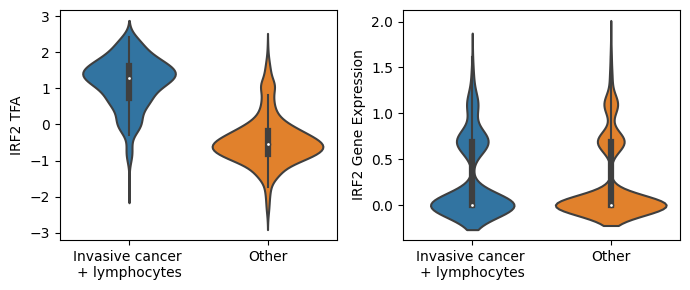

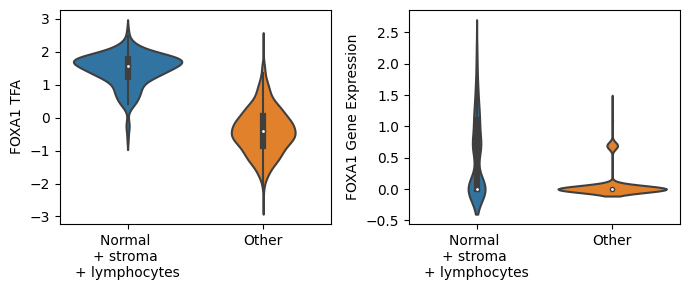

In [28]:
fig, axs=plt.subplots(1,2,figsize=(7,3))
x=(adata.obs['pathology']=="Invasive cancer + lymphocytes").map({True: "Invasive cancer \n+ lymphocytes", False: "Other"})
sns.violinplot(y=adata.to_df()["IRF2"], x=x, ax=axs[0], order=["Invasive cancer \n+ lymphocytes", "Other"])
sns.violinplot(y=np.log(adata.to_df("gex")["IRF2"]+1), x=x, ax=axs[1], order=["Invasive cancer \n+ lymphocytes", "Other"])
axs[0].set_ylabel("IRF2 TFA")
axs[1].set_ylabel("IRF2 Gene Expression")
axs[0].set_xlabel("")
axs[1].set_xlabel("")
plt.tight_layout()


fig, axs=plt.subplots(1,2,figsize=(7,3))
x=(adata.obs['pathology']=="Normal + stroma + lymphocytes").map({True: "Normal \n+ stroma \n+ lymphocytes", False: "Other"})
sns.violinplot(y=adata.to_df()["FOXA1"], x=x, ax=axs[0], order=["Normal \n+ stroma \n+ lymphocytes", "Other"])
sns.violinplot(y=np.log(adata.to_df("gex")["FOXA1"]+1), x=x, ax=axs[1], order=["Normal \n+ stroma \n+ lymphocytes", "Other"])
axs[0].set_ylabel("FOXA1 TFA")
axs[1].set_ylabel("FOXA1 Gene Expression")
axs[0].set_xlabel("")
axs[1].set_xlabel("")
plt.tight_layout()

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


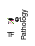

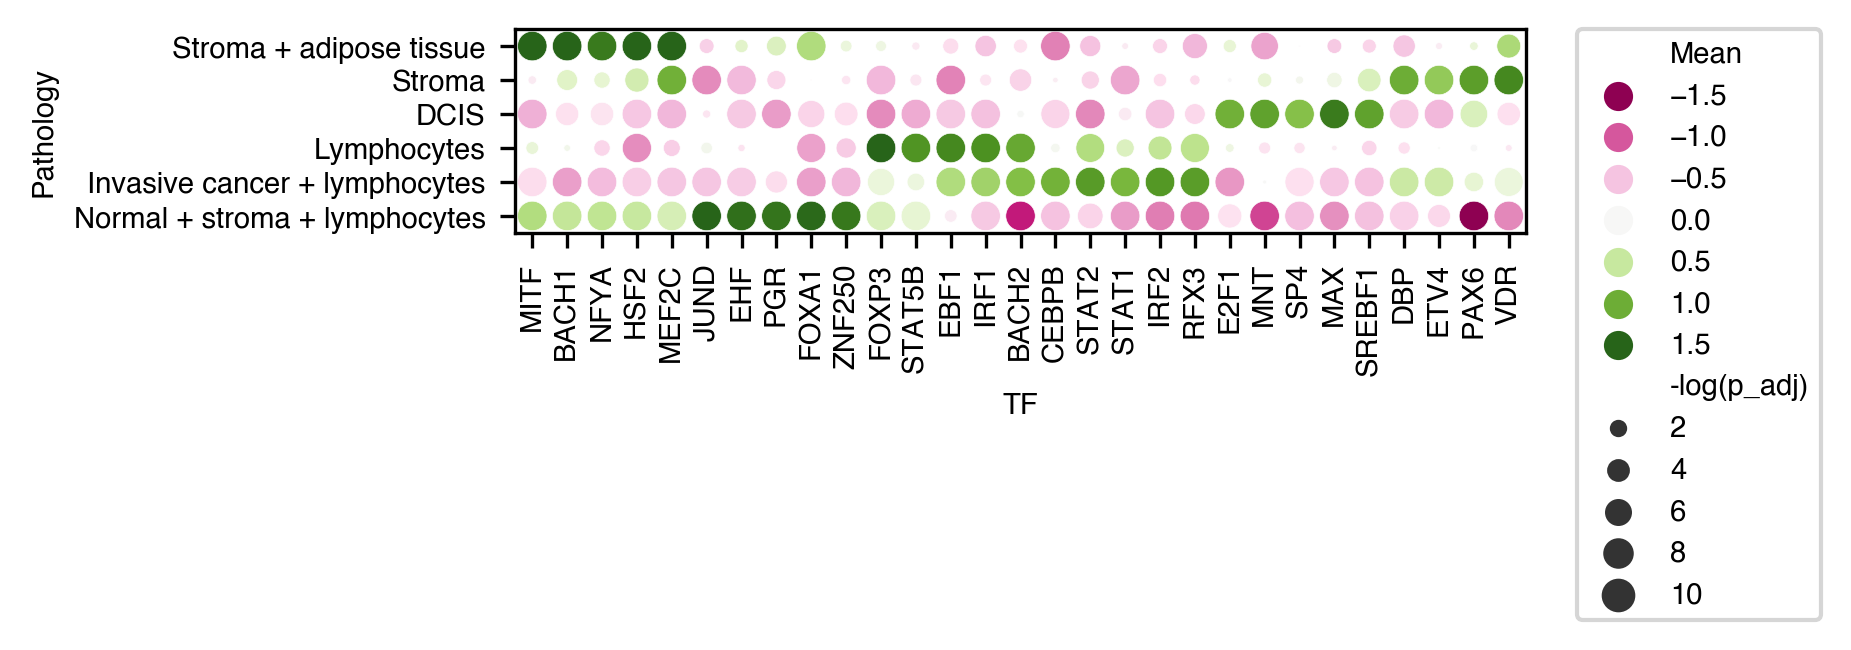

In [23]:
categories=adata.obs['pathology'].cat.categories
mean_df=adata.to_df().groupby(adata.obs['pathology']).mean()
df=[]
for i in range(len(adata.uns['rank_genes_groups']['names'])):
    for j, cat in enumerate(categories):
        tf=adata.uns['rank_genes_groups']['names'][i][j]
        pval=adata.uns['rank_genes_groups']['pvals_adj'][i][j]
        mean=mean_df.loc[cat, tf]
        df.append([tf, cat, mean, -np.log10(pval+1e-10), i])
df=pd.DataFrame(df, columns=['TF', 'Pathology', 'Mean', '-log(p_adj)', 'rank'])
top_tfs=[ x for sub in adata.uns['rank_genes_groups']['names'][0:5] for x in sub]
df=df.query("TF in @top_tfs")
df['TF']=df['TF'].astype("category")
df['TF']=df['TF'].cat.remove_unused_categories()
dotplot(df, x="TF", y='Pathology', color="Mean", size="-log(p_adj)", colors=(-1.5,1.5))
plt.savefig("CID44971_pathology_dotplot.pdf", bbox_inches='tight')

Trying to set attribute `.uns` of view, copying.
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


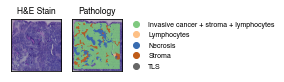

<Figure size 432x288 with 0 Axes>

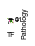

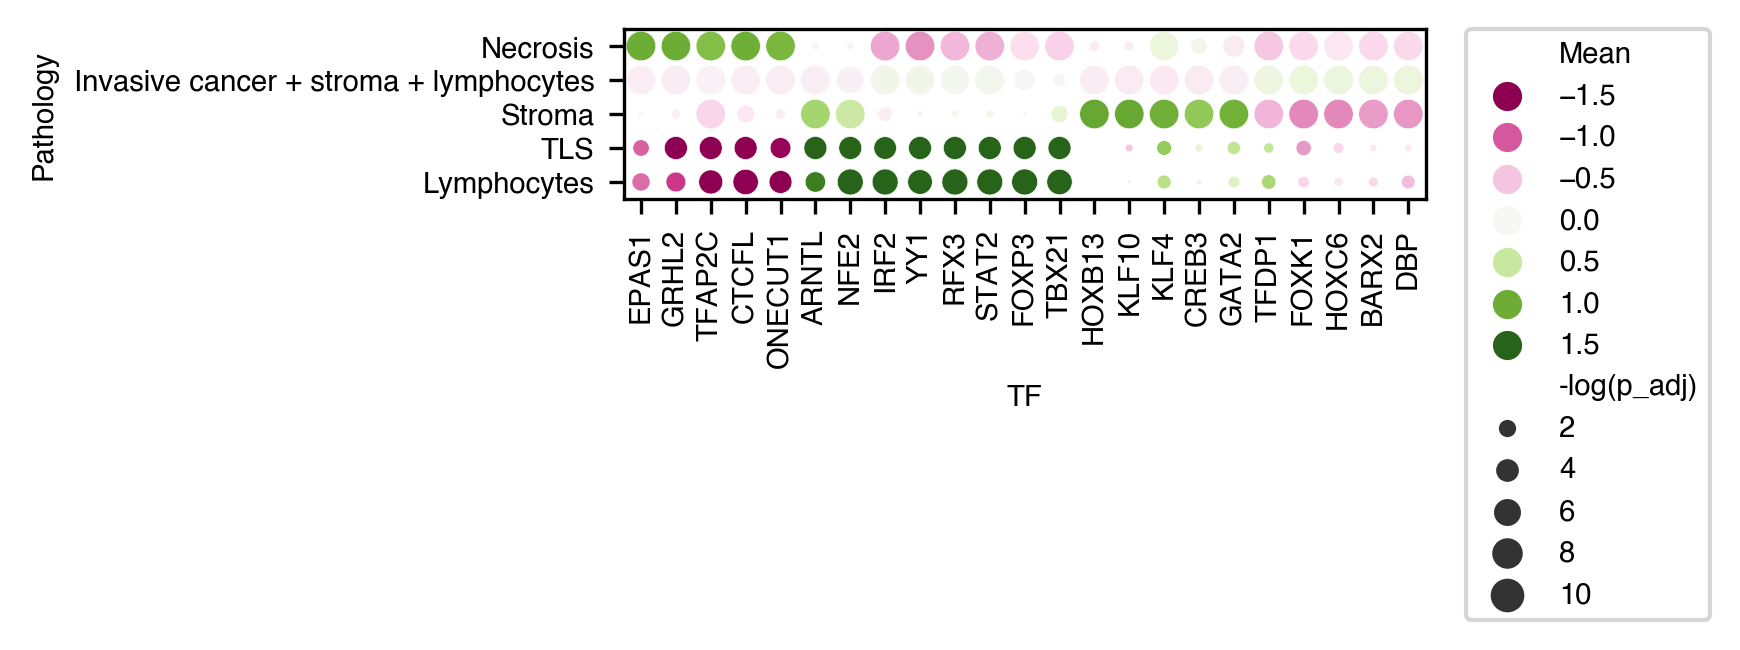

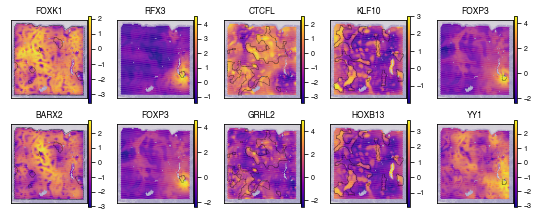

In [45]:
adata=sc.read_h5ad("out/1142243Fstf_results_tfa_only.h5ad")
sample='1142243F'
adata=adata[adata.obs['pathology'] !="Artefact"]
adata=adata[adata.obs['pathology'] !="Uncertain"]
adata=adata[adata.obs['pathology'] !=np.nan]
f,axs=plt.subplots(1,2,figsize=(2,2))
sc.pl.spatial(adata, color=[None], size=2, palette='Accent', show=False, ax=axs[0], title='H&E Stain')
sc.pl.spatial(adata, color=['pathology'], size=2, palette='Accent', show=False, ax=axs[1], title='Pathology')

axs[0].set_xlabel("")
axs[0].set_ylabel("")
axs[1].set_xlabel("")
axs[1].set_ylabel("")
plt.savefig('figures/'+sample+"diff_exp_pathology.pdf", bbox_inches='tight', padding_inches=0)


sc.tl.rank_genes_groups(adata, layer='stan_tfa', groupby='pathology', method="wilcoxon")



plt.figure()
categories=adata.obs['pathology'].cat.categories
mean_df=adata.to_df().groupby(adata.obs['pathology']).mean()
df=[]
for i in range(len(adata.uns['rank_genes_groups']['names'])):
    for j, cat in enumerate(categories):
        tf=adata.uns['rank_genes_groups']['names'][i][j]
        pval=adata.uns['rank_genes_groups']['pvals_adj'][i][j]
        mean=mean_df.loc[cat, tf]
        df.append([tf, cat, mean, -np.log10(pval+1e-10), i])
df=pd.DataFrame(df, columns=['TF', 'Pathology', 'Mean', '-log(p_adj)', 'rank'])
top_tfs=[ x for sub in adata.uns['rank_genes_groups']['names'][0:5] for x in sub]
df=df.query("TF in @top_tfs")
df['TF']=df['TF'].astype("category")
df['TF']=df['TF'].cat.remove_unused_categories()
dotplot(df, x="TF", y='Pathology', color="Mean", size="-log(p_adj)", colors=(-1.5,1.5))
plt.savefig('figures/'+sample+"diff_exp_dotplot.pdf", bbox_inches='tight', padding_inches=0)


f, axs = plt.subplots(2, len(categories), figsize=(1.5*len(categories),3))
for i in range(len(categories)):
    points=np.asarray(adata[adata.obs['pathology']==categories[i]].obsm['spatial']*adata.uns['spatial'][sample]['scalefactors']['tissue_hires_scalef'])
    points=np.vstack((points +[-10,10], points +[-10,-10], points +[10,10], points +[10,-10]))
    edges=alpha_shape(points, alpha=25, only_outer=True)
    for j in range(2):
        sc.pl.spatial(adata, color=adata.uns['rank_genes_groups']['names'][j][i], size=1.8, cmap='plasma', alpha_img=0.5, ax=axs[j,i], show=False)
        axs[j,i].set_xlabel("")
        axs[j,i].set_ylabel("")
        for ii, jj in edges:
            axs[j,i].plot(points[[ii, jj], 0], points[[ii, jj], 1], 'k', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('figures/'+sample+"diff_exp_TFA.pdf", bbox_inches='tight', padding_inches=0)


Trying to set attribute `.uns` of view, copying.
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


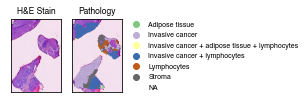

<Figure size 432x288 with 0 Axes>

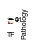

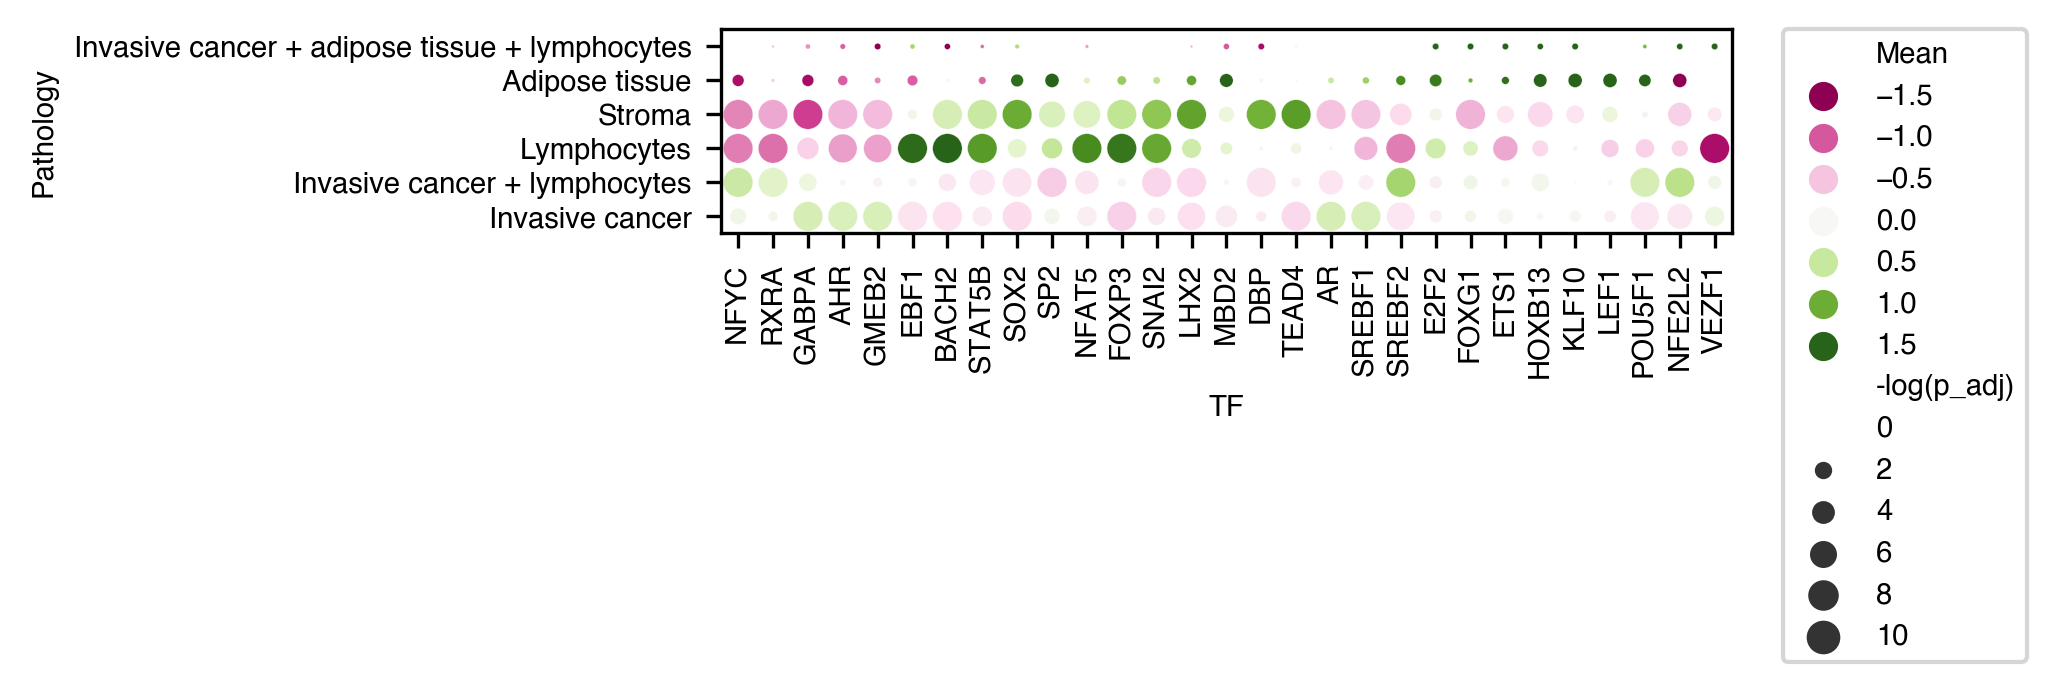

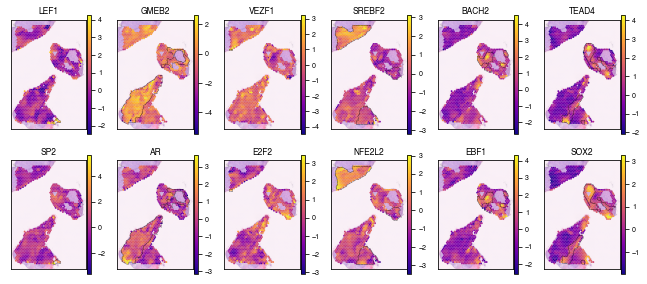

In [46]:
adata=sc.read_h5ad("out/CID4535stf_results_tfa_only.h5ad")
sample="CID4535"
adata=adata[adata.obs['pathology'] !="Artefact"]
adata=adata[adata.obs['pathology'] !="Uncertain"]
adata=adata[adata.obs['pathology'] !=np.nan]

adata=adata[adata.obs['pathology'] !="Artefact"]
adata=adata[adata.obs['pathology'] !="Uncertain"]
adata=adata[adata.obs['pathology'] !=np.nan]
f,axs=plt.subplots(1,2,figsize=(2,2))
sc.pl.spatial(adata, color=[None], size=2, palette='Accent', show=False, ax=axs[0], title='H&E Stain')
sc.pl.spatial(adata, color=['pathology'], size=2, palette='Accent', show=False, ax=axs[1], title='Pathology')

axs[0].set_xlabel("")
axs[0].set_ylabel("")
axs[1].set_xlabel("")
axs[1].set_ylabel("")
plt.savefig('figures/'+sample+"diff_exp_pathology.pdf", bbox_inches='tight', padding_inches=0)



sc.tl.rank_genes_groups(adata, layer='stan_tfa', groupby='pathology', method="wilcoxon")



plt.figure()
categories=adata.obs['pathology'].cat.categories
mean_df=adata.to_df().groupby(adata.obs['pathology']).mean()
df=[]
for i in range(len(adata.uns['rank_genes_groups']['names'])):
    for j, cat in enumerate(categories):
        tf=adata.uns['rank_genes_groups']['names'][i][j]
        pval=adata.uns['rank_genes_groups']['pvals_adj'][i][j]
        mean=mean_df.loc[cat, tf]
        df.append([tf, cat, mean, -np.log10(pval+1e-10), i])
df=pd.DataFrame(df, columns=['TF', 'Pathology', 'Mean', '-log(p_adj)', 'rank'])
top_tfs=[ x for sub in adata.uns['rank_genes_groups']['names'][0:5] for x in sub]
df=df.query("TF in @top_tfs")
df['TF']=df['TF'].astype("category")
df['TF']=df['TF'].cat.remove_unused_categories()
dotplot(df, x="TF", y='Pathology', color="Mean", size="-log(p_adj)", colors=(-1.5,1.5))
plt.savefig('figures/'+sample+"diff_exp_dotplot.pdf", bbox_inches='tight', padding_inches=0)


f, axs = plt.subplots(2, len(categories), figsize=(1.5*len(categories),4))
for i in range(len(categories)):
    points=np.asarray(adata[adata.obs['pathology']==categories[i]].obsm['spatial']*adata.uns['spatial'][sample]['scalefactors']['tissue_hires_scalef'])
    points=np.vstack((points +[-10,10], points +[-10,-10], points +[10,10], points +[10,-10]))
    edges=alpha_shape(points, alpha=25, only_outer=True)
    for j in range(2):
        sc.pl.spatial(adata, color=adata.uns['rank_genes_groups']['names'][j][i], size=1.7, cmap='plasma', alpha_img=0.5, ax=axs[j,i], show=False)
        axs[j,i].set_xlabel("")
        axs[j,i].set_ylabel("")
        for ii, jj in edges:
            axs[j,i].plot(points[[ii, jj], 0], points[[ii, jj], 1], 'k', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('figures/'+sample+"diff_exp_TFA.pdf", bbox_inches='tight', padding_inches=0)


Trying to set attribute `.uns` of view, copying.
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


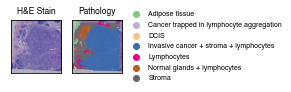

<Figure size 432x288 with 0 Axes>

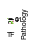

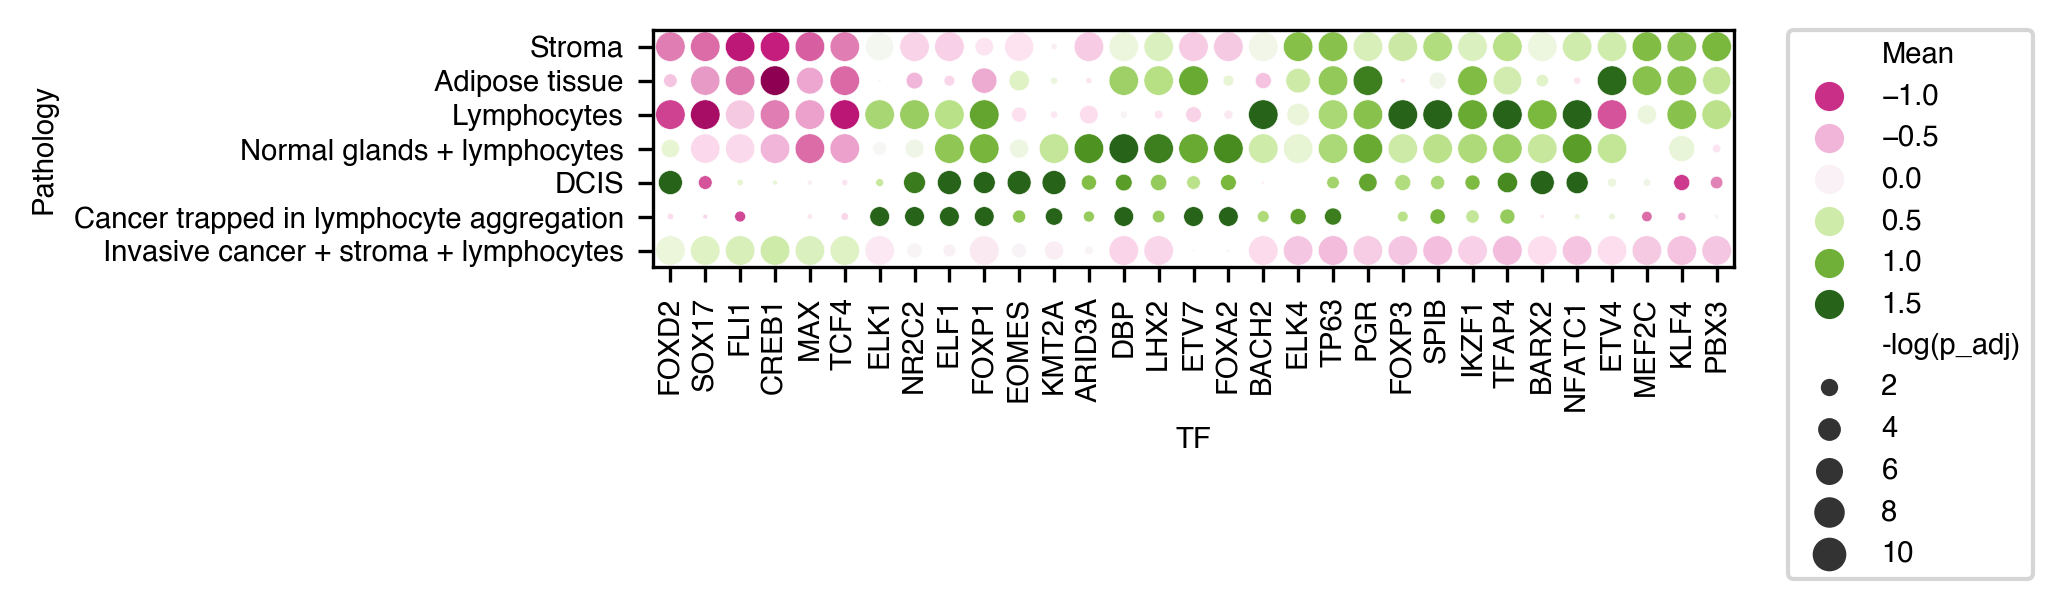

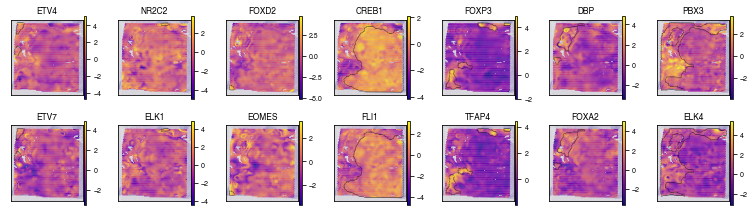

In [47]:
adata=sc.read_h5ad("out/1160920Fstf_results_tfa_only.h5ad")
sample="1160920F"
adata=adata[adata.obs['pathology'] !="Artefact"]
adata=adata[adata.obs['pathology'] !="Uncertain"]
adata=adata[adata.obs['pathology'] !=np.nan]
f,axs=plt.subplots(1,2,figsize=(2,2))
sc.pl.spatial(adata, color=[None], size=2, palette='Accent', show=False, ax=axs[0], title='H&E Stain')
sc.pl.spatial(adata, color=['pathology'], size=2, palette='Accent', show=False, ax=axs[1], title='Pathology')

axs[0].set_xlabel("")
axs[0].set_ylabel("")
axs[1].set_xlabel("")
axs[1].set_ylabel("")

plt.savefig('figures/'+sample+"diff_exp_pathology.pdf", bbox_inches='tight', padding_inches=0)

sc.tl.rank_genes_groups(adata, layer='stan_tfa', groupby='pathology', method="wilcoxon")



plt.figure()
categories=adata.obs['pathology'].cat.categories
mean_df=adata.to_df().groupby(adata.obs['pathology']).mean()
df=[]
for i in range(len(adata.uns['rank_genes_groups']['names'])):
    for j, cat in enumerate(categories):
        tf=adata.uns['rank_genes_groups']['names'][i][j]
        pval=adata.uns['rank_genes_groups']['pvals_adj'][i][j]
        mean=mean_df.loc[cat, tf]
        df.append([tf, cat, mean, -np.log10(pval+1e-10), i])
df=pd.DataFrame(df, columns=['TF', 'Pathology', 'Mean', '-log(p_adj)', 'rank'])
top_tfs=[ x for sub in adata.uns['rank_genes_groups']['names'][0:5] for x in sub]
df=df.query("TF in @top_tfs")
df['TF']=df['TF'].astype("category")
df['TF']=df['TF'].cat.remove_unused_categories()
dotplot(df, x="TF", y='Pathology', color="Mean", size="-log(p_adj)", colors=(-1.5,1.5))
plt.savefig('figures/'+sample+"diff_exp_dotplot.pdf", bbox_inches='tight', padding_inches=0)


f, axs = plt.subplots(2, len(categories), figsize=(1.5*len(categories),3))
for i in range(len(categories)):
    points=np.asarray(adata[adata.obs['pathology']==categories[i]].obsm['spatial']*adata.uns['spatial'][sample]['scalefactors']['tissue_hires_scalef'])
    points=np.vstack((points +[-10,10], points +[-10,-10], points +[10,10], points +[10,-10]))
    edges=alpha_shape(points, alpha=25, only_outer=True)
    for j in range(2):
        sc.pl.spatial(adata, color=adata.uns['rank_genes_groups']['names'][j][i], size=1.7, cmap='plasma', alpha_img=0.5, ax=axs[j,i], show=False)
        axs[j,i].set_xlabel("")
        axs[j,i].set_ylabel("")
        for ii, jj in edges:
            axs[j,i].plot(points[[ii, jj], 0], points[[ii, jj], 1], 'k', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('figures/'+sample+"diff_exp_TFA.pdf", bbox_inches='tight', padding_inches=0)


# Compare Pathology accross samples


In [2]:
df=[]
for sample in ["CID44971","CID4535","CID4290","1142243F","CID4465","1160920F"]:
    adata=sc.read_h5ad("out/"+sample+"stf_results_tfa_only.h5ad")
    adata=adata[adata.obs['pathology'] !="Artefact"]
    adata=adata[adata.obs['pathology'] !="Uncertain"]
    adata=adata[adata.obs['pathology'] !=np.nan]
    sc.tl.rank_genes_groups(adata, layer='stan_tfa', groupby='pathology', method="wilcoxon")

    categories=adata.obs['pathology'].cat.categories
    mean_df=adata.to_df().groupby(adata.obs['pathology']).mean()
    for i in range(len(adata.uns['rank_genes_groups']['names'])):
        for j, cat in enumerate(categories):
            tf=adata.uns['rank_genes_groups']['names'][i][j]
            pval=adata.uns['rank_genes_groups']['pvals_adj'][i][j]
            mean=mean_df.loc[cat, tf]
            df.append([sample, tf, cat, mean, pval, i/adata.n_vars])
df=pd.DataFrame(df, columns=['Sample','TF', 'Pathology', 'Mean', 'p_adj', 'rank'])

df[["Pathology", "Sample"]].value_counts().unstack()>0


Trying to set attribute `.uns` of view, copying.
Trying to set attribute `.uns` of view, copying.
Trying to set attribute `.uns` of view, copying.
Trying to set attribute `.uns` of view, copying.
Trying to set attribute `.uns` of view, copying.
Trying to set attribute `.uns` of view, copying.


Sample,1142243F,1160920F,CID4290,CID4465,CID44971,CID4535
Pathology,,,,,,
Adipose tissue,False,True,False,False,False,True
Cancer trapped in lymphocyte aggregation,False,True,False,False,False,False
DCIS,False,True,False,False,True,False
Invasive cancer,False,False,False,False,False,True
Invasive cancer + adipose tissue + lymphocytes,False,False,False,False,False,True
Invasive cancer + lymphocytes,False,False,False,False,True,True
Invasive cancer + stroma,False,False,True,False,False,False
Invasive cancer + stroma + lymphocytes,True,True,True,True,False,False
Lymphocytes,True,True,False,False,True,True


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


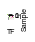

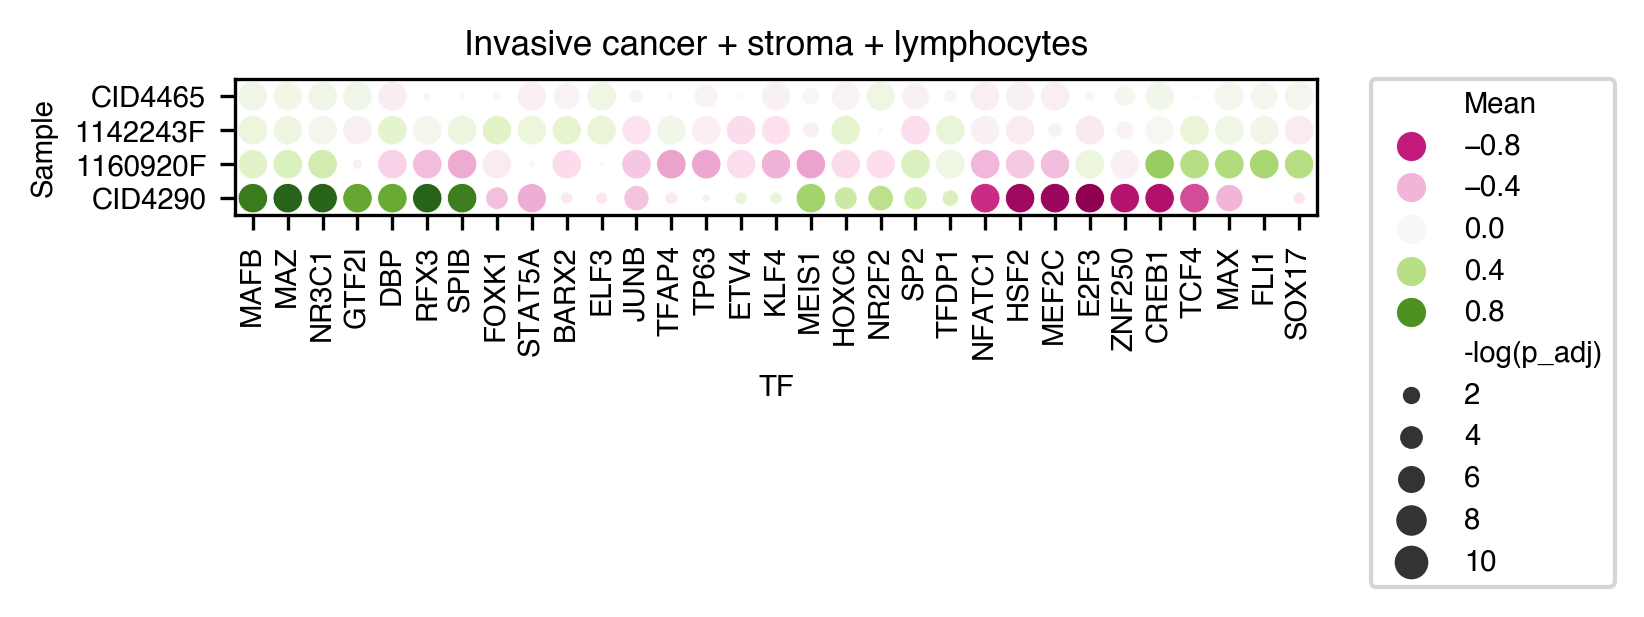

In [74]:
plt.rcParams['pdf.fonttype']=42
plt.rcParams.update({'font.sans-serif':'Helvetica'})
plt.rcParams.update({'font.size':7})
df['-log(p_adj)']=-np.log10(df['p_adj']+1e-10)
tfs=df.query("Pathology=='Invasive cancer + stroma + lymphocytes' and (rank<0.02 or rank>0.98)")['TF'].unique() #get top 5% for each sample
tfs=df.query("Pathology=='Invasive cancer + stroma + lymphocytes' and TF in @tfs").pivot(index="Sample", columns="TF", values="Mean").dropna(axis=1).columns #only keep tfs with in all samples
df_subset=df.query("Pathology=='Invasive cancer + stroma + lymphocytes' and TF in @tfs")

df_subset['TF']=df_subset['TF'].astype("category")
df_subset['TF']=df_subset['TF'].cat.remove_unused_categories()
dotplot(df_subset, x="TF", y='Sample', color="Mean", size="-log(p_adj)", colors=(-1,1))
plt.title("Invasive cancer + stroma + lymphocytes")
plt.savefig("Wu_icsl_dotplot.pdf", bbox_inches='tight', pad_inches=0)

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


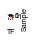

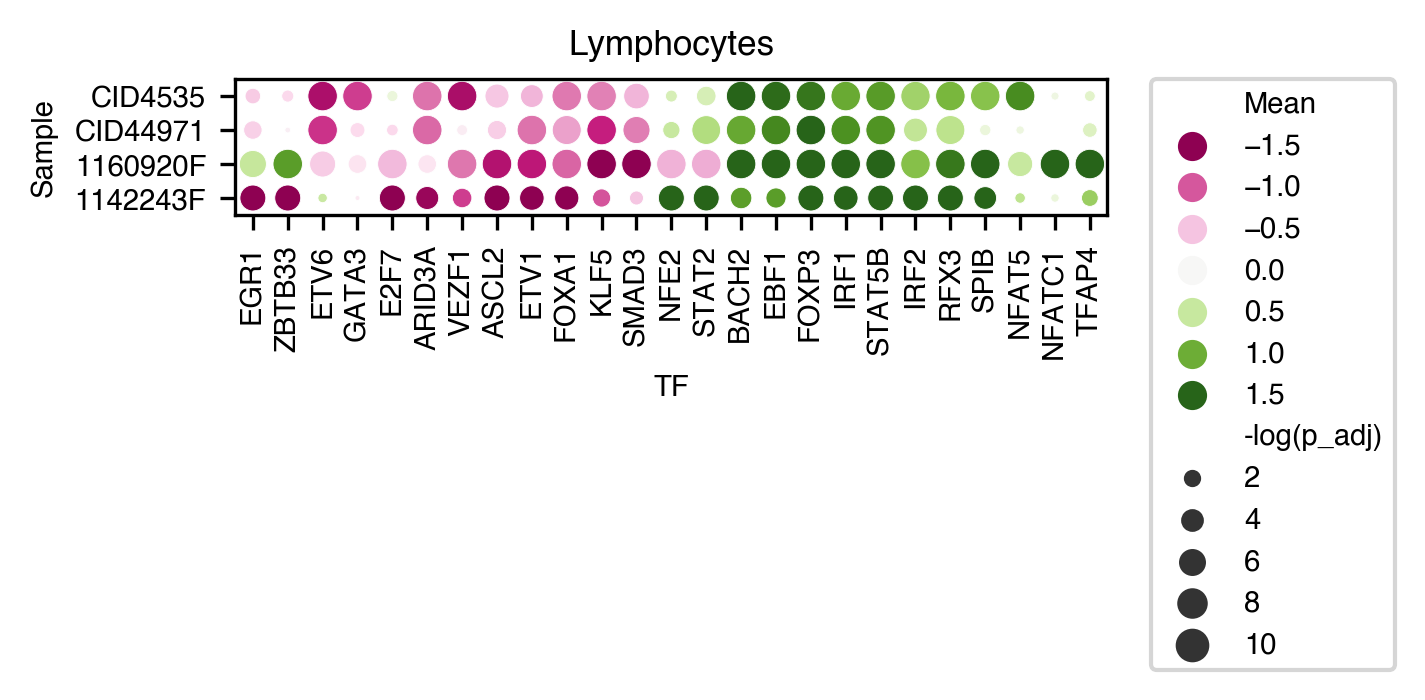

In [75]:
df['-log(p_adj)']=-np.log10(df['p_adj']+1e-10)
tfs=df.query("Pathology=='Lymphocytes' and (rank<0.02 or rank>0.98)")['TF'].unique() #get top 5% for each sample
tfs=df.query("Pathology=='Lymphocytes' and TF in @tfs").pivot(index="Sample", columns="TF", values="Mean").dropna(axis=1).columns #only keep tfs with in all samples
df_subset=df.query("Pathology=='Lymphocytes' and TF in @tfs")

df_subset['TF']=df_subset['TF'].astype("category")
df_subset['TF']=df_subset['TF'].cat.remove_unused_categories()
ax=dotplot(df_subset, x="TF", y='Sample', color="Mean", size="-log(p_adj)", colors=(-1.5, 1.5))
# ax.legend(ncol=14,loc='lower left', bbox_to_anchor=(-0.1,-1.5),columnspacing=0.6,handletextpad=0)
plt.title("Lymphocytes")
plt.savefig("Wu_Lymphocytes_dotplot.pdf", bbox_inches='tight', pad_inches=0)

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


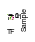

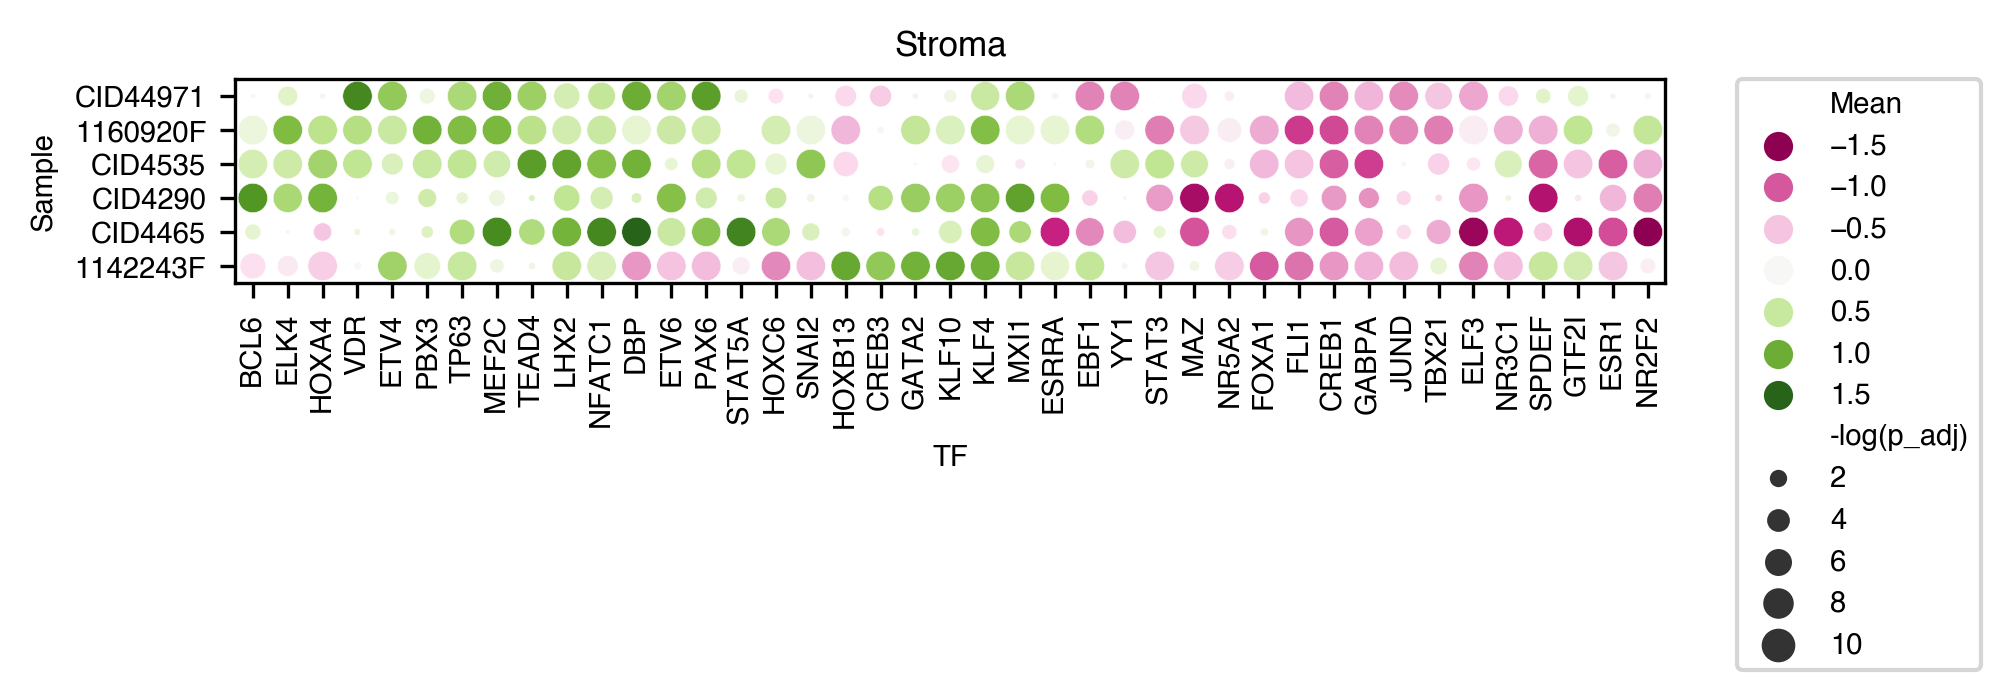

In [76]:
df['-log(p_adj)']=-np.log10(df['p_adj']+1e-10)
tfs=df.query("Pathology=='Stroma' and (rank<0.02 or rank>0.98)")['TF'].unique() #get top 5% for each sample
tfs=df.query("Pathology=='Stroma' and TF in @tfs").pivot(index="Sample", columns="TF", values="Mean").dropna(axis=1).columns #only keep tfs with in all samples
df_subset=df.query("Pathology=='Stroma' and TF in @tfs")

df_subset['TF']=df_subset['TF'].astype("category")
df_subset['TF']=df_subset['TF'].cat.remove_unused_categories()
dotplot(df_subset, x="TF", y='Sample', color="Mean", size="-log(p_adj)", colors=(-1.5, 1.5))
plt.title("Stroma")
plt.savefig("Wu_stroma_dotplot.pdf", bbox_inches='tight', pad_inches=0)

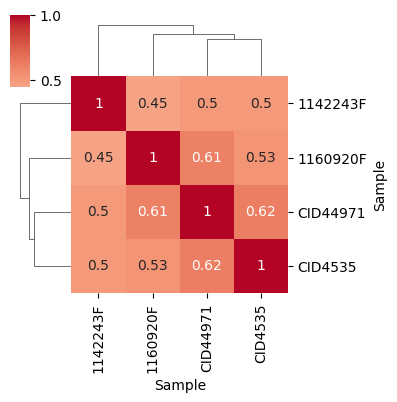

In [36]:
sns.clustermap(df.query("Pathology=='Lymphocytes'").pivot(columns="Sample", index="TF", values="Mean").dropna().corr().round(2),
               cmap="coolwarm", center=0, annot=True, figsize=(4,4))

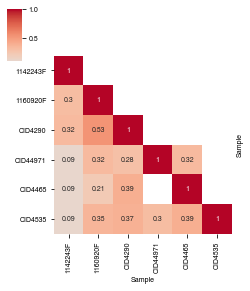

In [64]:

g=sns.clustermap(df.query("Pathology=='Stroma'").pivot(columns="Sample", index="TF", values="Mean").dropna().corr().round(2),
               cmap="coolwarm", center=0, annot=True, figsize=(4,4), mask=np.tril(np.ones(6)-np.eye(6)).T)
g.ax_col_dendrogram.set_visible(False)
g.ax_row_dendrogram.set_visible(False)

g.ax_heatmap.yaxis.set_ticks_position("left")

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


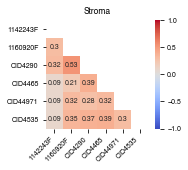

In [68]:
plt.figure(figsize=(2.3,2))

ax=sns.heatmap(df.query("Pathology=='Stroma'").pivot(columns="Sample", index="TF", values="Mean").dropna().corr().round(2),
            cmap="coolwarm", center=0, annot=True, mask=np.tril(np.ones(6)).T, vmax=1, vmin=-1)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, ha='right')
plt.title("Stroma")
plt.savefig("figures/path_mean_tfa_stroma.pdf", bbox_inches='tight', pad_inches=0)

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


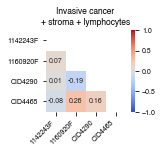

In [66]:

plt.figure(figsize=(1.8,1.5))
ax=sns.heatmap(df.query("Pathology=='Invasive cancer + stroma + lymphocytes'").pivot(columns="Sample", index="TF", values="Mean").dropna().corr().round(2),
            cmap="coolwarm", center=0, annot=True, mask=np.tril(np.ones(4)).T, vmax=1, vmin=-1)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, ha='right')
plt.title("Invasive cancer \n+ stroma + lymphocytes")
plt.savefig("figures/path_mean_tfa_ISL.pdf", bbox_inches='tight', pad_inches=0)

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


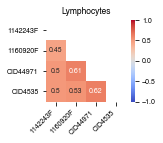

In [67]:
plt.figure(figsize=(1.8,1.5))
ax=sns.heatmap(df.query("Pathology=='Lymphocytes'").pivot(columns="Sample", index="TF", values="Mean").dropna().corr().round(2),cmap="coolwarm", center=0, annot=True, mask=np.tril(np.ones(4)).T, vmax=1, vmin=-1)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, ha='right')
plt.title("Lymphocytes")
plt.savefig("figures/path_mean_tfa_Lymphocytes.pdf", bbox_inches='tight', pad_inches=0)

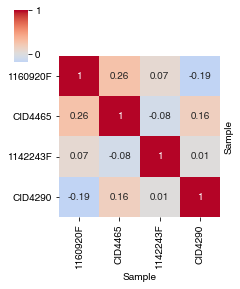

In [59]:
g = sns.clustermap(df.query("Pathology=='Invasive cancer + stroma + lymphocytes'").pivot(columns="Sample", index="TF", values="Mean").dropna().corr().round(2),
               cmap="coolwarm", center=0, annot=True, figsize=(4,4))
g.ax_col_dendrogram.set_visible(False)
g.ax_row_dendrogram.set_visible(False)

g.ax_heatmap.yaxis.set_ticks_position("left")